In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_pct)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


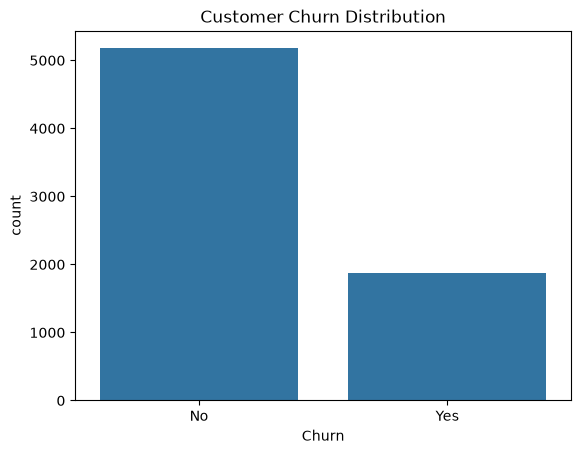

In [4]:
sns.countplot(data=df, x='Churn')
plt.title("Customer Churn Distribution")
plt.show()

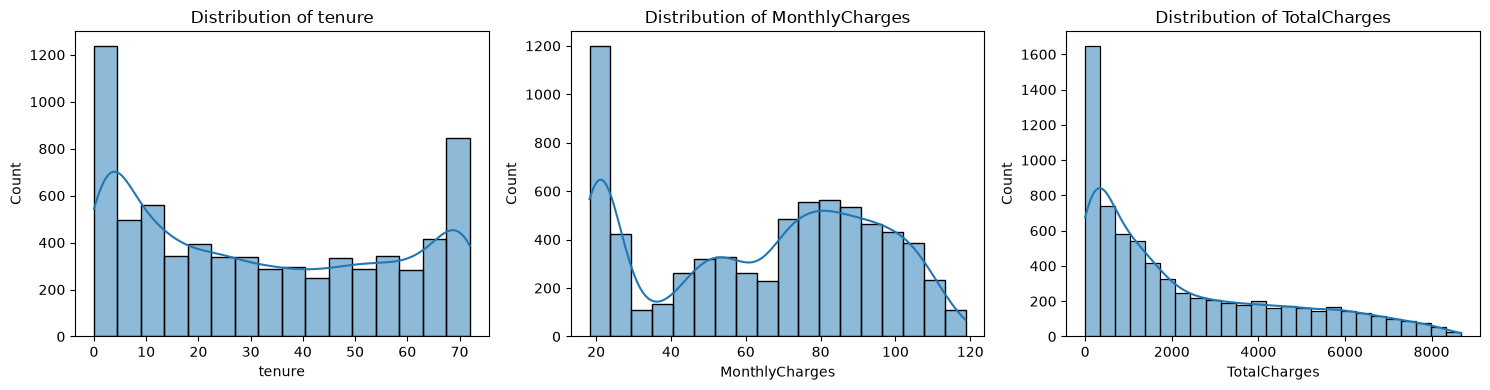

In [6]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

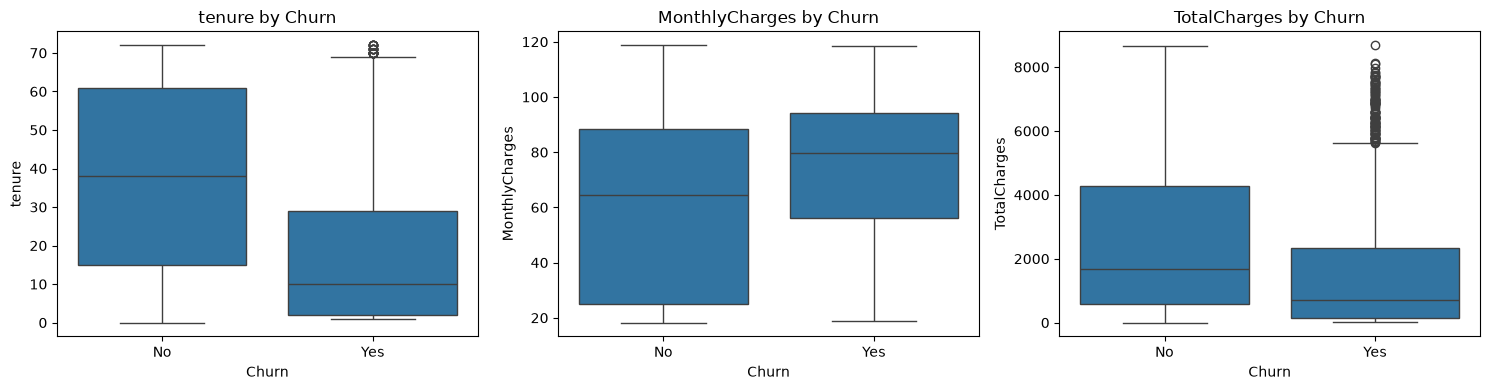

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i])
    axes[i].set_title(f"{col} by Churn")
plt.tight_layout()
plt.show()

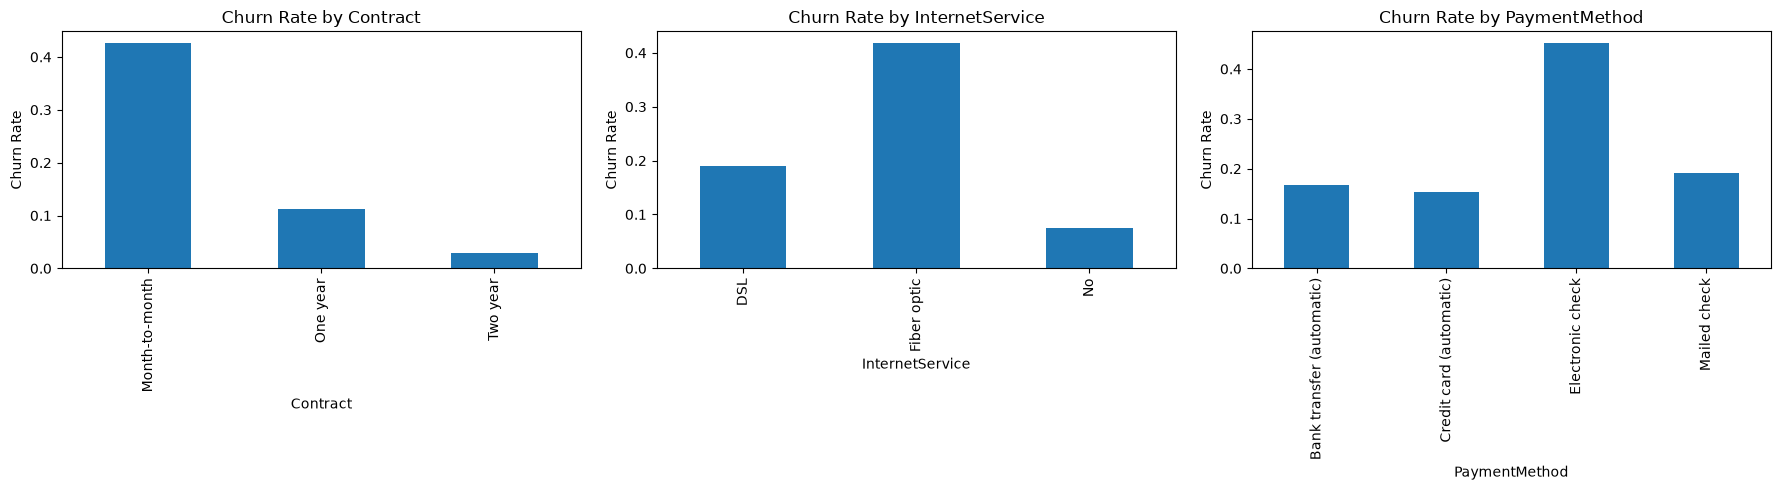

In [9]:
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    churn_rate.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()

In [11]:
from scipy.stats import chi2_contingency

In [12]:
contingency_table = pd.crosstab(df['Contract'], df['Churn'])
print(contingency_table)

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


In [13]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2 statistic: {chi2:.2f}")
print(f"p_value: {p_value}")

Chi2 statistic: 1184.60
p_value: 5.863038300673391e-258


In [14]:
from scipy.stats import ttest_ind

In [15]:
churned = df[df['Churn'] == 'Yes']['tenure']
retained = df[df['Churn'] == 'No']['tenure']

In [16]:
t_stat, p_value = ttest_ind(churned, retained)
print(f"T-statistic: {t_stat:.2f}")
print(f"p-value: {p_value}")

T-statistic: -31.58
p-value: 7.999057960590134e-205


In [17]:
contingency_table = pd.crosstab(df['gender'], df['Churn'])
print(contingency_table)

Churn     No  Yes
gender           
Female  2549  939
Male    2625  930


In [18]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2 statistic: {chi2:.2f}")
print(f"p_value: {p_value}")

Chi2 statistic: 0.48
p_value: 0.48657873605618596


In [19]:
def tenure_group(t):
    if t <= 12:
        return '0-1yr'
    elif t <= 24:
        return '1-2yr'
    elif t <= 48:
        return '2-4yr'
    else:
        return '4yr+'

df['TenureGroup'] = df['tenure'].apply(tenure_group)
print(df['TenureGroup'].value_counts())

TenureGroup
4yr+     2239
0-1yr    2186
2-4yr    1594
1-2yr    1024
Name: count, dtype: int64


In [20]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['TotalServices'] = (df[service_cols] == 'Yes').sum(axis=1)
print(df['TotalServices'].value_counts().sort_index())

TotalServices
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64


In [21]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'SeniorCitizen', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [22]:
print(df[binary_cols].head())

   Partner  Dependents  PhoneService  MultipleLines  OnlineSecurity  \
0        1           0             0              0               0   
1        0           0             1              0               1   
2        0           0             1              0               1   
3        0           0             0              0               1   
4        0           0             1              0               0   

   OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  \
0             1                 0            0            0                0   
1             0                 1            0            0                0   
2             1                 0            0            0                0   
3             0                 1            1            0                0   
4             0                 0            0            0                0   

   PaperlessBilling  SeniorCitizen  Churn  
0                 1              0      0  
1   

In [23]:
multi_cat_cols = ['gender', 'InternetService', 'Contract', 'PaymentMethod', 'TenureGroup']

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)
print(df.columns.tolist())

['customerID', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TotalServices', 'gender_Male', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TenureGroup_1-2yr', 'TenureGroup_2-4yr', 'TenureGroup_4yr+']


In [24]:
df = df.drop('customerID', axis=1)

In [25]:
df.to_csv("../data/processed/telco_churn_features.csv", index=False)
print(df.shape)

(7043, 28)


In [26]:
df.dtypes

SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
TotalServices                              int64
gender_Male                                 bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
Contract_One year   

In [27]:
df['SeniorCitizen'].unique()

array([0, 1])